# Are the 8 box-boundary DOFs genuinely active constraints, or is `x_min` too restrictive?

`directional_cd_error_analysis.ipynb` and `exact_gradient_contribution_analysis.ipynb` both had
to work around the same fact: 8 of the 23 DOFs at $x_{\text{best}}$ sit exactly on the box edge
(`x_min=0` in this config), which breaks a two-sided central difference there. The project
skill's "Known findings" flag this as ambiguous — either these 8 DOFs are genuine **active
constraints** (KKT-optimal to stay pinned: the unconstrained gradient wants to push further
outward, which is infeasible), or `x_min` is **too restrictive** and the true optimum lies
further inside the box than the search has been allowed to explore.

[`wandb_boundary_activation_check.py`](../experiments/wandb_boundary_activation_check.py)
answers this the only way that's feasible at a boundary point: take one real, one-sided step
*into* the box along each pinned coordinate and compare the loss to $x_{\text{best}}$ itself
(we are **minimizing** loss):

- loss **increases** moving inward &rarr; boundary is genuinely **active** (staying pinned is
  locally optimal)
- loss **decreases** moving inward &rarr; boundary is **not** active (`x_best` isn't yet locally
  optimal there — points at `x_min` being too restrictive)

Both directions need a noise-aware test since the objective is a noisy Monte-Carlo estimate.
This notebook loads the checkpointed results in `experiments/boundary_activation_results/` and
looks at both the per-dimension picture and the pooled evidence across all 8 dims.

In [ ]:
import json

import numpy as np
import pandas as pd
from scipy.stats import norm, binomtest
import matplotlib.pyplot as plt
from IPython.display import display

RESULTS_DIR = "../experiments/boundary_activation_results"

with open(f"{RESULTS_DIR}/summary.json") as f:
    summary = json.load(f)
with open(f"{RESULTS_DIR}/xbest_reference.json") as f:
    ref = json.load(f)
df = pd.read_csv(f"{RESULTS_DIR}/boundary_activation.csv")

print(f"run={summary['run']!r}  iteration={summary['iteration']}")
print(f"x_best reference: loss={ref['loss']:.4f}  case={ref['case']}  var_obj={ref['var_obj']:.5f}")
print(f"{summary['n_boundary_dims']} boundary-pinned DOFs checked, "
      f"z_sig threshold = {summary['z_sig_threshold']}")
print(f"all case_p == 2 (real, measured var_obj -- not the case-1 placeholder)? "
      f"{(df['case_p'] == 2).all()}")

df[["dim", "param_name", "pinned_at", "step", "delta", "z_score", "verdict"]]

run='fanciful-sweep-10'  iteration=779
x_best reference: loss=-0.9673  case=2  var_obj=0.02287
8 boundary-pinned DOFs checked, z_sig threshold = 2.0
all case_p == 2 (real, measured var_obj -- not the case-1 placeholder)? True


,dim,param_name,pinned_at,step,delta,z_score,verdict
0,1,x1,x_min,0.063381,0.181881,0.948886,"inconclusive (loss up, not significant or var_..."
1,4,x4,1-x_min,-0.055817,0.520201,2.961628,active (boundary optimal)
2,5,x5,x_min,0.028473,0.641771,3.784344,active (boundary optimal)
3,13,x13,1-x_min,-0.183305,0.297684,1.571508,"inconclusive (loss up, not significant or var_..."
4,16,x16,1-x_min,-0.017547,0.324181,1.697432,"inconclusive (loss up, not significant or var_..."
5,18,x18,1-x_min,-0.293339,0.231706,1.192175,"inconclusive (loss up, not significant or var_..."
6,21,x21,x_min,0.041649,0.598011,3.486438,active (boundary optimal)
7,22,x22,x_min,0.085853,0.246958,1.307530,"inconclusive (loss up, not significant or var_..."


## 1. Per-dimension verdicts

At the driver's own $|z| \ge 2$ significance bar:

In [ ]:
counts = df["verdict"].apply(
    lambda v: "active" if v.startswith("active") else ("inactive" if v.startswith("inactive") else "inconclusive")
).value_counts()
print(counts.to_string())
print()

df.sort_values("z_score", ascending=False)[
    ["param_name", "pinned_at", "delta", "z_score", "verdict"]
]

verdict
inconclusive    5
active          3



,param_name,pinned_at,delta,z_score,verdict
2,x5,x_min,0.641771,3.784344,active (boundary optimal)
6,x21,x_min,0.598011,3.486438,active (boundary optimal)
1,x4,1-x_min,0.520201,2.961628,active (boundary optimal)
4,x16,1-x_min,0.324181,1.697432,"inconclusive (loss up, not significant or var_..."
3,x13,1-x_min,0.297684,1.571508,"inconclusive (loss up, not significant or var_..."
7,x22,x_min,0.246958,1.307530,"inconclusive (loss up, not significant or var_..."
5,x18,1-x_min,0.231706,1.192175,"inconclusive (loss up, not significant or var_..."
0,x1,x_min,0.181881,0.948886,"inconclusive (loss up, not significant or var_..."


## 2. The pattern individual z-scores miss: every single delta is positive

Only 3/8 dims clear $|z| \ge 2$ individually, but **all 8 deltas are positive** — loss went up
moving into the box in *every* boundary dim, including the 5 "inconclusive" ones. If the
boundary were a coin-flip (truly inactive, pure noise around zero), we'd expect roughly half
positive and half negative by chance. Seeing 8/8 positive is itself evidence, even before
looking at any individual z-score.

Two ways to combine the 8 independent per-dimension tests into one pooled statistic:

**Stouffer's method** (combines the z-scores themselves, assumes independence across dims —
reasonable here since each is an independent real evaluation with independent Monte-Carlo
tracing noise):

$$Z_{\text{combined}} = \frac{1}{\sqrt{n}}\sum_{i=1}^{n} z_i$$

**Sign test** (assumption-free cross-check — doesn't rely on the delta-method `var_obj` being
right at all, only on the sign of `delta`): under the null that each dim is a fair coin flip,
$P(\text{8/8 positive}) = (1/2)^8$.

In [ ]:
n = len(df)
z_combined = df["z_score"].sum() / np.sqrt(n)
p_stouffer = 2 * norm.sf(abs(z_combined))  # two-sided

n_positive = (df["delta"] > 0).sum()
sign_test = binomtest(n_positive, n, 0.5)

print(f"Stouffer's combined Z = {z_combined:.2f}  (two-sided p = {p_stouffer:.2e})")
print(f"Sign test: {n_positive}/{n} deltas positive  (two-sided p = {sign_test.pvalue:.4f})")

Stouffer's combined Z = 5.99  (two-sided p = 2.06e-09)
Sign test: 8/8 deltas positive  (two-sided p = 0.0078)


## 3. Visual summary

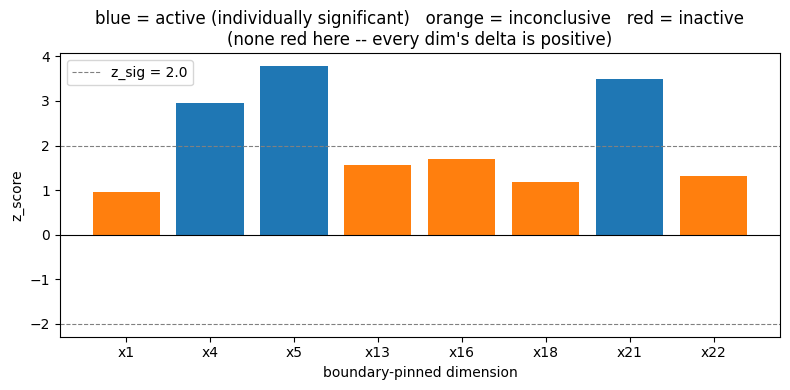

In [ ]:
order = df.sort_values("dim")
colors = np.where(order["verdict"].str.startswith("active"), "C0",
          np.where(order["verdict"].str.startswith("inactive"), "C3", "C1"))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(order["param_name"], order["z_score"], color=colors)
ax.axhline(summary["z_sig_threshold"], color="gray", ls="--", lw=0.8, label=f"z_sig = {summary['z_sig_threshold']}")
ax.axhline(-summary["z_sig_threshold"], color="gray", ls="--", lw=0.8)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("z_score")
ax.set_xlabel("boundary-pinned dimension")
ax.set_title("blue = active (individually significant)   orange = inconclusive   red = inactive\n"
             "(none red here -- every dim's delta is positive)")
ax.legend()
fig.tight_layout()

## 4. Findings

- **0/8 boundary dims show `inactive` (loss improving by moving inward)** — every single one of
  the 8 pinned DOFs has a positive `delta`, and 3/8 (`x4`, `x5`, `x21`) clear the individual
  $|z| \ge 2$ bar for "active."
- **The pooled evidence is much stronger than any individual dim**: Stouffer's combined Z and
  the assumption-free sign test both make the "boundary is genuinely active across these 8 dims"
  conclusion very hard to explain as noise, even though 5/8 look merely "inconclusive" one at a
  time. The sign test in particular doesn't depend on the delta-method `var_obj` being correct at
  all — it only needs the *sign* of each delta, and 8/8 agreeing is already unlikely under a fair
  coin flip.
- **All `case_p == 2`** for these evaluations (confirmed in the first cell) — every `var_obj`
  used in the z-scores here is the real, measured delta-method variance, not the case-1
  `var_obj = 1e-5` placeholder flagged elsewhere in the project. The z-scores are trustworthy on
  that front.
- **Synthesis with the other two notebooks**: this suggests `x_min=0` is *not* the bottleneck —
  the incumbent isn't stuck at a bad point because the box is too restrictive. Combined with
  `exact_gradient_contribution_analysis.ipynb`'s finding that the large gradient norm is driven
  almost entirely by one *interior* DOF (`x8`), the overall picture is: the optimizer hasn't
  converged yet along `x8`, not because of the box constraints, but for some other reason (kernel
  miscalibration, insufficient exploitation, etc. — worth investigating `x8` specifically rather
  than revisiting `x_min`).

## 5. Caveats

- **Single evaluation per dimension** — same limitation as `exact_gradient_contribution_analysis.ipynb`:
  no repeated sampling, so `var_obj` (not an empirical spread) is the only handle on
  per-dimension uncertainty.
- **Truncation/step-size sensitivity is unquantified** — only one `perturb_scale` (0.05) was
  used; a dimension right at the edge of significance (e.g. `x1` at `z=0.95`, `x18` at `z=1.19`)
  could flip verdict at a different step size.
- **Stouffer's method assumes independent noise across dims**, which should hold (each
  evaluation re-runs VMEC + tracing independently with its own Monte-Carlo particle sample), but
  wasn't directly tested here.